# 02 — Equivalent endpoint escape formulation

This notebook studies `EquivalentNarrowEscape`, where absorption is detected from the proposed **endpoint** entering a small target region near the boundary. The target is represented by a superellipse centred at `(1, 0)`:

$[
\left|\frac{x-1}{\epsilon_r}\right|^p
+
\left|\frac{y}{\epsilon_t}\right|^p \leq 1.
]$

The former ambiguous parameters `epsilon1` and `epsilon2` are renamed:

- `epsilon_r`: radial half-size of the equivalent target;
- `epsilon_t`: tangential half-size;
- `p`: shape exponent (`p=2` gives an ellipse, large `p` approaches a rectangle).

The notebook preserves the original geometric study but organizes it around four interpretable outputs: one trajectory, a two-parameter response surface, shape sensitivity, and a comparison with the direct boundary-window formulation.


## Environment and execution profile

The quick profile is intended for interactive work. The full profile increases the number of repetitions and parameter values. Numerical results are cached as JSON so figures can be regenerated without repeating the simulations.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from scipy import stats

from stage_escape import (
    BrownianMotion,
    EquivalentNarrowEscape,
    Escape,
    NaiveNarrowEscape,
    Surface,
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


In [2]:
QUICK_RUN = True
FORCE_RECOMPUTE = False
N_JOBS = -1
BASE_SEED = 20260718

D = 1.0
DELTA_T = 5.0e-4
DEPOSITION_STRIDE = 100

if QUICK_RUN:
    RADIAL_SIZES = np.array([0.02, 0.04, 0.08, 0.16])
    TANGENTIAL_SIZES = np.array([0.04, 0.08, 0.16, 0.32])
    POWERS = np.array([1.0, 1.5, 2.0, 4.0, 8.0])
    WINDOW_SIZES = np.geomspace(0.50, 0.05, 7)
    N_REPLICATES_GRID = 16
    N_REPLICATES_SHAPE = 28
    N_REPLICATES_COMPARISON = 24
    MAX_STEPS = 600_000
else:
    RADIAL_SIZES = np.geomspace(0.01, 0.25, 8)
    TANGENTIAL_SIZES = np.geomspace(0.025, 0.40, 9)
    POWERS = np.array([1.0, 1.25, 1.5, 2.0, 3.0, 4.0, 8.0, 16.0])
    WINDOW_SIZES = np.geomspace(0.50, 0.02, 13)
    N_REPLICATES_GRID = 100
    N_REPLICATES_SHAPE = 150
    N_REPLICATES_COMPARISON = 120
    MAX_STEPS = 3_000_000

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_DIR = REPO_ROOT / "artifacts"
CACHE_DIR = ARTIFACT_DIR / "notebook_cache"
FIGURE_DIR = ARTIFACT_DIR / "figures" / "02_equivalent_narrow_escape"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROFILE = "quick" if QUICK_RUN else "full"


In [3]:
def spawned_seeds(base_seed: int, count: int) -> list[int]:
    sequence = np.random.SeedSequence(base_seed)
    return [int(child.generate_state(1, dtype=np.uint32)[0]) for child in sequence.spawn(count)]


def confidence_summary(values, confidence: float = 0.95) -> dict[str, float]:
    sample = np.asarray(values, dtype=float)
    sample = sample[np.isfinite(sample)]
    n = sample.size
    if n == 0:
        return {"n": 0, "mean": np.nan, "std": np.nan, "sem": np.nan, "ci": np.nan}
    mean = float(np.mean(sample))
    if n == 1:
        return {"n": 1, "mean": mean, "std": np.nan, "sem": np.nan, "ci": np.nan}
    std = float(np.std(sample, ddof=1))
    sem = std / np.sqrt(n)
    ci = float(stats.t.ppf(0.5 + confidence / 2.0, df=n - 1) * sem)
    return {"n": int(n), "mean": mean, "std": std, "sem": sem, "ci": ci}


def summarize_records(records: list[dict], parameters: tuple[str, ...]) -> list[dict]:
    keys = sorted({tuple(float(record[name]) for name in parameters) for record in records})
    summary = []
    for key in keys:
        group = [
            record
            for record in records
            if all(np.isclose(record[name], value) for name, value in zip(parameters, key, strict=True))
        ]
        escaped_times = [record["escape_time"] for record in group if record["escaped"]]
        statistics = confidence_summary(escaped_times)
        row = {name: value for name, value in zip(parameters, key, strict=True)}
        row.update(statistics)
        row.update(
            {
                "attempts": len(group),
                "escape_fraction": float(np.mean([record["escaped"] for record in group])),
                "mean_rejection_fraction": float(
                    np.mean([record["rejection_fraction"] for record in group])
                ),
            }
        )
        summary.append(row)
    return summary


def load_or_compute(cache_path: Path, compute) -> list[dict]:
    if cache_path.exists() and not FORCE_RECOMPUTE:
        with cache_path.open("r", encoding="utf-8") as stream:
            return json.load(stream)
    records = compute()
    with cache_path.open("w", encoding="utf-8") as stream:
        json.dump(records, stream, indent=2)
    return records


def save_figure(fig, filename: str) -> None:
    fig.savefig(FIGURE_DIR / filename, bbox_inches="tight")


## Geometry and simulation factories

The equivalent target overlaps the neighbourhood of the boundary point. This is intentional: endpoint absorption is checked before an exterior proposal is rejected, so the same predicate can absorb proposals on either side of the geometric boundary.


In [4]:
def unit_disk() -> Surface:
    return Surface("unit disk", [lambda point: point[0] ** 2 + point[1] ** 2 - 1.0])


def equivalent_target(
    epsilon_r: float,
    epsilon_t: float,
    power: float = 2.0,
) -> Escape:
    if epsilon_r <= 0.0 or epsilon_t <= 0.0:
        raise ValueError("Target half-sizes must be strictly positive.")
    if power < 1.0:
        raise ValueError("The superellipse exponent must be at least one.")

    return Escape(
        [
            lambda point, er=epsilon_r, et=epsilon_t, p=power: (
                abs((point[0] - 1.0) / er) ** p
                + abs(point[1] / et) ** p
                <= 1.0
            )
        ]
    )


def direct_window(epsilon: float) -> Escape:
    return Escape(
        [
            lambda point: point[0] > 0.0,
            lambda point, eps=epsilon: abs(point[1]) <= eps / 2.0,
        ]
    )


def make_motion(seed: int) -> BrownianMotion:
    return BrownianMotion(
        deposition_stride=DEPOSITION_STRIDE,
        delta_t=DELTA_T,
        dimension=2,
        D=D,
        initial_position=np.zeros(2),
        seed=seed,
    )


def simulate_equivalent(
    epsilon_r: float,
    epsilon_t: float,
    power: float,
    seed: int,
    keep_result: bool = False,
):
    simulation = EquivalentNarrowEscape(
        make_motion(seed),
        unit_disk(),
        [equivalent_target(epsilon_r, epsilon_t, power)],
    )
    result = simulation.run(max_steps=MAX_STEPS)
    if keep_result:
        return simulation, result
    return {
        "epsilon_r": float(epsilon_r),
        "epsilon_t": float(epsilon_t),
        "power": float(power),
        "seed": int(seed),
        "escaped": bool(result.escaped),
        "escape_time": None if result.escape_time is None else float(result.escape_time),
        "attempted_steps": int(result.attempted_steps),
        "rejection_fraction": float(result.rejected_steps / max(result.attempted_steps, 1)),
    }


## 1. Geometry and one representative trajectory

This first figure verifies that the target geometry, trajectory, and endpoint absorption agree visually before any parameter sweep is interpreted.


{'epsilon_r': 0.08, 'epsilon_t': 0.16, 'power': 2.0, 'escaped': True, 'escape_time': 0.613, 'attempted_steps': 1226, 'rejected_steps': 10}


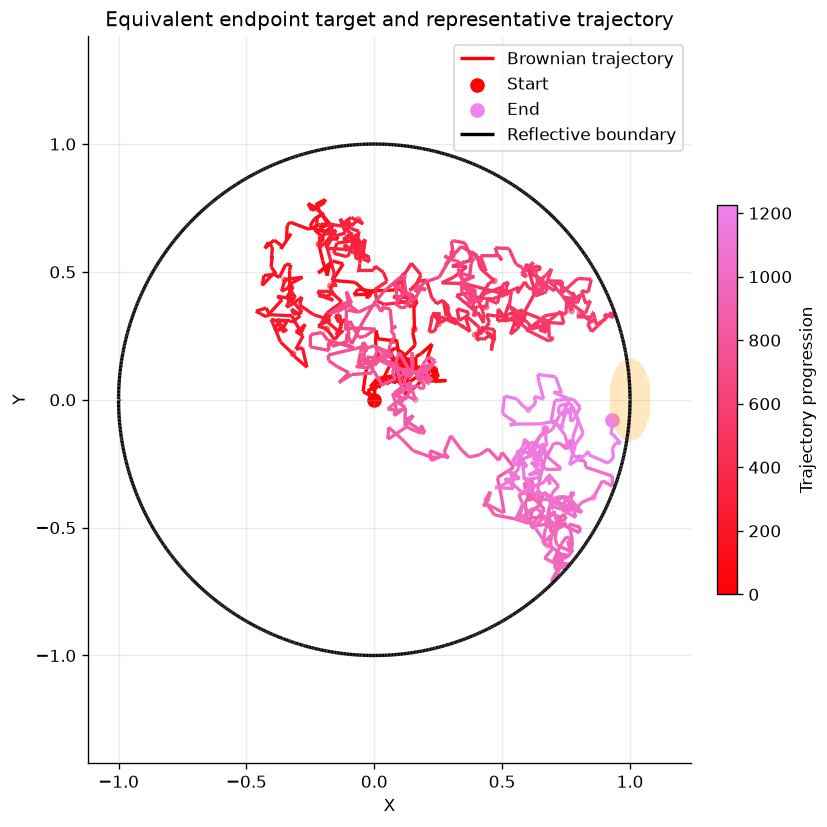

In [5]:
representative_parameters = {
    "epsilon_r": 0.08,
    "epsilon_t": 0.16,
    "power": 2.0,
}
representative_seed = spawned_seeds(BASE_SEED, 1)[0]
representative_simulation, representative_result = simulate_equivalent(
    **representative_parameters,
    seed=representative_seed,
    keep_result=True,
)

print(
    {
        **representative_parameters,
        "escaped": representative_result.escaped,
        "escape_time": representative_result.escape_time,
        "attempted_steps": representative_result.attempted_steps,
        "rejected_steps": representative_result.rejected_steps,
    }
)

fig, ax = representative_simulation.plot_narrow_escape_problem(
    xlim=(-1.08, 1.20),
    ylim=(-1.08, 1.08),
    point_stride=max(representative_result.attempted_steps // 40, 1),
    point_size=16,
    point_alpha=0.65,
    show_points=True,
    show=False,
)
ax.set_title("Equivalent endpoint target and representative trajectory")
fig.tight_layout()
save_figure(fig, "01_equivalent_geometry_and_trajectory.png")
plt.show()


## 2. Response surface in `epsilon_r` and `epsilon_t`

The two geometric scales have different roles. `epsilon_t` controls how much of the boundary neighbourhood is accessible tangentially, whereas `epsilon_r` controls the radial thickness of the endpoint target and therefore its sensitivity to the time step and proposal overshoot.

A heatmap is more informative than several unrelated line plots because it shows both effects and their interaction in one figure.


In [6]:
def compute_geometry_grid() -> list[dict]:
    tasks = [
        (float(epsilon_r), float(epsilon_t), replicate)
        for epsilon_r in RADIAL_SIZES
        for epsilon_t in TANGENTIAL_SIZES
        for replicate in range(N_REPLICATES_GRID)
    ]
    seeds = spawned_seeds(BASE_SEED + 1, len(tasks))
    return Parallel(n_jobs=N_JOBS)(
        delayed(simulate_equivalent)(epsilon_r, epsilon_t, 2.0, seed)
        for (epsilon_r, epsilon_t, _), seed in zip(tasks, seeds, strict=True)
    )


geometry_records = load_or_compute(
    CACHE_DIR / f"02_equivalent_geometry_grid_{PROFILE}.json",
    compute_geometry_grid,
)
geometry_summary = summarize_records(geometry_records, ("epsilon_r", "epsilon_t"))

mean_grid = np.full((len(RADIAL_SIZES), len(TANGENTIAL_SIZES)), np.nan)
escape_grid = np.full_like(mean_grid, np.nan)
for row in geometry_summary:
    i = int(np.flatnonzero(np.isclose(RADIAL_SIZES, row["epsilon_r"]))[0])
    j = int(np.flatnonzero(np.isclose(TANGENTIAL_SIZES, row["epsilon_t"]))[0])
    mean_grid[i, j] = row["mean"]
    escape_grid[i, j] = row["escape_fraction"]

print(f"Minimum escape fraction in grid: {np.nanmin(escape_grid):.3f}")


Minimum escape fraction in grid: 1.000


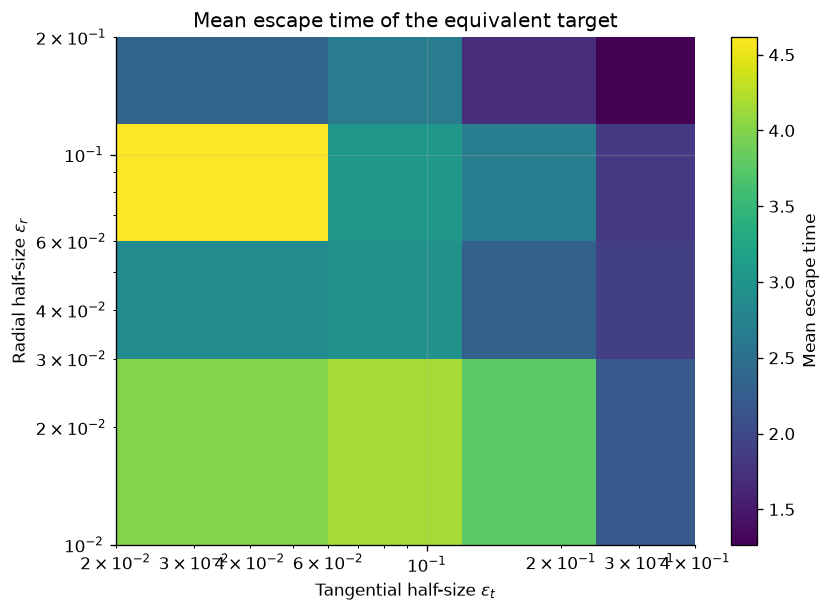

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
mesh = ax.pcolormesh(
    TANGENTIAL_SIZES,
    RADIAL_SIZES,
    mean_grid,
    shading="nearest",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(
    xlabel=r"Tangential half-size $\epsilon_t$",
    ylabel=r"Radial half-size $\epsilon_r$",
)
ax.set_title("Mean escape time of the equivalent target")
colorbar = fig.colorbar(mesh, ax=ax)
colorbar.set_label("Mean escape time")
fig.tight_layout()
save_figure(fig, "02_equivalent_geometry_response_surface.png")
plt.show()


## 3. Sensitivity to the superellipse exponent

At fixed half-sizes, changing `p` isolates the influence of target shape without changing its axial extents. This answers the original power-parameter question directly and attaches uncertainty to each estimate.


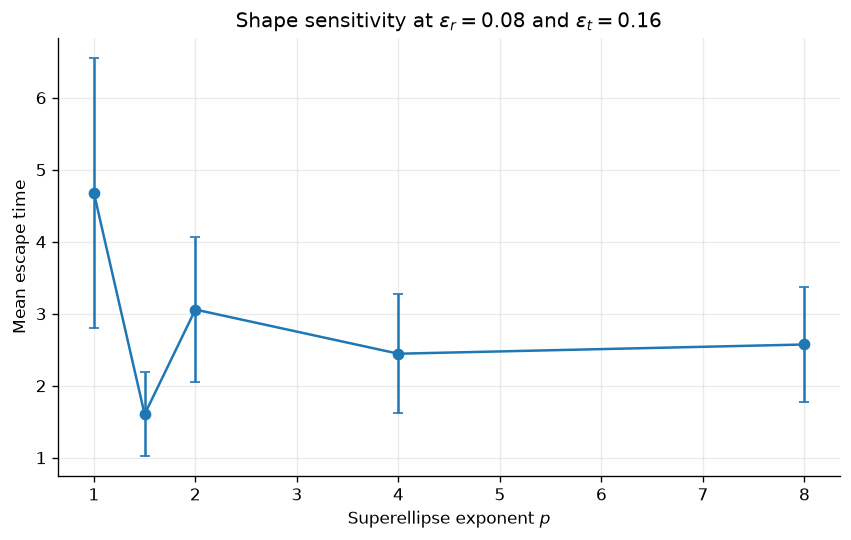

In [8]:
SHAPE_EPSILON_R = 0.08
SHAPE_EPSILON_T = 0.16


def compute_shape_sweep() -> list[dict]:
    tasks = [(float(power), replicate) for power in POWERS for replicate in range(N_REPLICATES_SHAPE)]
    seeds = spawned_seeds(BASE_SEED + 2, len(tasks))
    return Parallel(n_jobs=N_JOBS)(
        delayed(simulate_equivalent)(
            SHAPE_EPSILON_R,
            SHAPE_EPSILON_T,
            power,
            seed,
        )
        for (power, _), seed in zip(tasks, seeds, strict=True)
    )


shape_records = load_or_compute(
    CACHE_DIR / f"02_equivalent_shape_{PROFILE}.json",
    compute_shape_sweep,
)
shape_summary = summarize_records(shape_records, ("power",))

power = np.array([row["power"] for row in shape_summary])
mean_time = np.array([row["mean"] for row in shape_summary])
ci_time = np.array([row["ci"] for row in shape_summary])

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.errorbar(power, mean_time, yerr=ci_time, marker="o", capsize=3)
ax.set(
    xlabel=r"Superellipse exponent $p$",
    ylabel="Mean escape time",
)
ax.set_title(
    rf"Shape sensitivity at $\epsilon_r={SHAPE_EPSILON_R}$ and "
    rf"$\epsilon_t={SHAPE_EPSILON_T}$"
)
fig.tight_layout()
save_figure(fig, "03_equivalent_shape_sensitivity.png")
plt.show()


## 4. Direct versus equivalent formulation

For a direct window of chord length `epsilon`, the tangential half-size of the equivalent target is set to `epsilon/2`. The radial half-size is tied to the typical Brownian proposal length,

$[
\epsilon_r = c\sqrt{2D\,\Delta t},
]$

with `c = 2` below. This makes the calibration explicit instead of treating the radial scale as an arbitrary second epsilon.

The objective is not to force exact equality for every window size. The useful comparison is whether both formulations reproduce the same trend and whether their ratio remains controlled over the investigated range.


In [9]:
RADIAL_STEP_MULTIPLIER = 2.0
CALIBRATED_EPSILON_R = RADIAL_STEP_MULTIPLIER * np.sqrt(2.0 * D * DELTA_T)


def simulate_direct_for_comparison(epsilon: float, seed: int) -> dict:
    simulation = NaiveNarrowEscape(make_motion(seed), unit_disk(), [direct_window(epsilon)])
    result = simulation.run(max_steps=MAX_STEPS)
    return {
        "method": "direct",
        "epsilon": float(epsilon),
        "seed": int(seed),
        "escaped": bool(result.escaped),
        "escape_time": None if result.escape_time is None else float(result.escape_time),
        "attempted_steps": int(result.attempted_steps),
        "rejection_fraction": float(result.rejected_steps / max(result.attempted_steps, 1)),
    }


def simulate_equivalent_for_comparison(epsilon: float, seed: int) -> dict:
    record = simulate_equivalent(
        epsilon_r=CALIBRATED_EPSILON_R,
        epsilon_t=epsilon / 2.0,
        power=2.0,
        seed=seed,
    )
    return {
        "method": "equivalent",
        "epsilon": float(epsilon),
        "seed": int(seed),
        "escaped": record["escaped"],
        "escape_time": record["escape_time"],
        "attempted_steps": record["attempted_steps"],
        "rejection_fraction": record["rejection_fraction"],
    }


def compute_method_comparison() -> list[dict]:
    tasks = [
        (method, float(epsilon), replicate)
        for method in ("direct", "equivalent")
        for epsilon in WINDOW_SIZES
        for replicate in range(N_REPLICATES_COMPARISON)
    ]
    seeds = spawned_seeds(BASE_SEED + 3, len(tasks))

    def execute(method: str, epsilon: float, seed: int) -> dict:
        if method == "direct":
            return simulate_direct_for_comparison(epsilon, seed)
        return simulate_equivalent_for_comparison(epsilon, seed)

    return Parallel(n_jobs=N_JOBS)(
        delayed(execute)(method, epsilon, seed)
        for (method, epsilon, _), seed in zip(tasks, seeds, strict=True)
    )


comparison_records = load_or_compute(
    CACHE_DIR / f"02_direct_equivalent_comparison_{PROFILE}.json",
    compute_method_comparison,
)


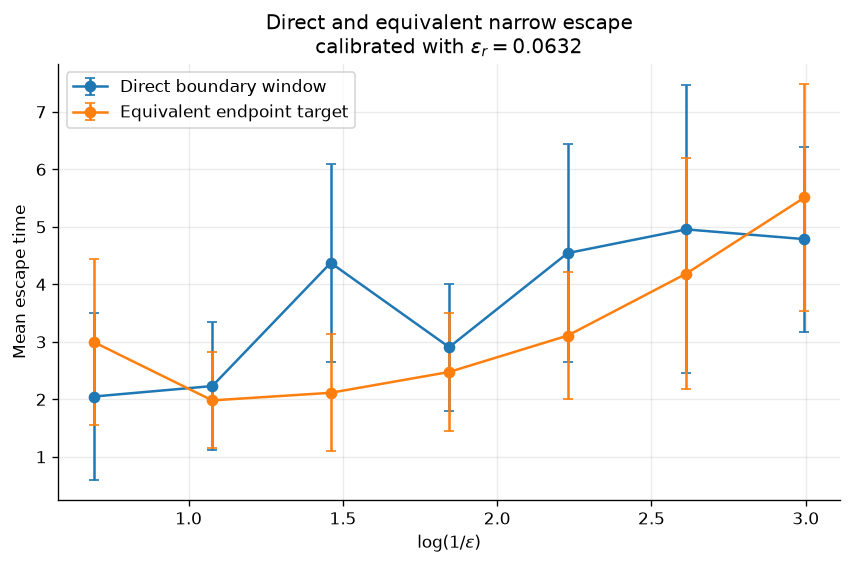

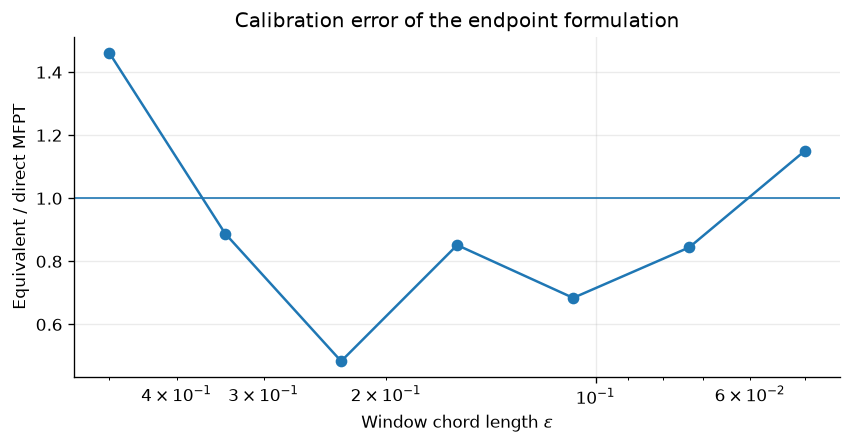

In [10]:
def summarize_method(records: list[dict], method: str) -> list[dict]:
    return summarize_records(
        [record for record in records if record["method"] == method],
        ("epsilon",),
    )


direct_summary = summarize_method(comparison_records, "direct")
equivalent_summary = summarize_method(comparison_records, "equivalent")

fig, ax = plt.subplots(figsize=(7.2, 4.8))
for label, summary in (("Direct boundary window", direct_summary), ("Equivalent endpoint target", equivalent_summary)):
    epsilon = np.array([row["epsilon"] for row in summary])
    mean = np.array([row["mean"] for row in summary])
    ci = np.array([row["ci"] for row in summary])
    ax.errorbar(
        np.log(1.0 / epsilon),
        mean,
        yerr=ci,
        marker="o",
        capsize=3,
        label=label,
    )

ax.set(xlabel=r"$\log(1/\epsilon)$", ylabel="Mean escape time")
ax.set_title(
    "Direct and equivalent narrow escape\n"
    + rf"calibrated with $\epsilon_r={CALIBRATED_EPSILON_R:.3g}$"
)
ax.legend()
fig.tight_layout()
save_figure(fig, "04_direct_vs_equivalent_scaling.png")
plt.show()

ratio = np.array([row["mean"] for row in equivalent_summary]) / np.array(
    [row["mean"] for row in direct_summary]
)
epsilon = np.array([row["epsilon"] for row in direct_summary])

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.axhline(1.0, linewidth=1.0)
ax.plot(epsilon, ratio, marker="o")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set(xlabel=r"Window chord length $\epsilon$", ylabel="Equivalent / direct MFPT")
ax.set_title("Calibration error of the endpoint formulation")
fig.tight_layout()
save_figure(fig, "05_equivalent_to_direct_ratio.png")
plt.show()


## Interpretation

- Increasing either target half-size should reduce the mean escape time, but the radial scale is also a numerical calibration parameter because the equivalent solver tests proposal endpoints.
- The power sweep determines whether conclusions are robust to the precise target shape. A strong dependence on `p` means that target area or local geometry must be controlled before comparing cases.
- The direct/equivalent ratio is the central calibration diagnostic. It should be reported together with `delta_t`, `epsilon_r`, and `epsilon_t`; otherwise the equivalent model is not reproducible.
- If the minimum escape fraction printed above is appreciably below one, increase `MAX_STEPS` before interpreting the affected means.
- A subsequent convergence study should repeat the comparison for several `delta_t` values while scaling `epsilon_r` with `sqrt(delta_t)`.
